# Healthcare Disease-Progression Early Warning

**Predict one-year diabetes disease progression using baseline clinical measurements, including age and sex.**

### Clinical / analytical question
Can baseline physiology, serum measurements and basic patient characteristics identify patients with elevated future disease-progression risk?

### Real dataset
This notebook uses scikit-learn's diabetes progression dataset:
- **442 patients**
- quantitative disease-progression outcome measured **one year after baseline**
- age, sex, BMI, average blood pressure and six serum measurements

### Feature policy
This version intentionally **keeps age and sex** alongside the clinical measurements.

**Model inputs:** age in years, source sex code, BMI, blood pressure, total serum cholesterol, LDL, HDL, total-cholesterol/HDL ratio, serum triglyceride-related signal and blood glucose.

Names and patient identifiers are not present. The sex field is retained as the dataset's numeric code rather than relabelled as male/female because the packaged dataset does not document that mapping explicitly.

### System design
- train / validation / untouched test split
- Ridge, Random Forest and HistGradientBoosting regression
- validation-selected champion model
- MAE, RMSE and R²
- distribution-free residual prediction intervals
- separate high-progression risk classifier
- ROC-AUC, PR-AUC, precision / recall / F1
- permutation importance
- age-band and sex-code subgroup performance audit
- ranked anonymised clinical-review queue

> **Educational decision-support project only. It is not a diagnostic tool or medical advice.**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Environment ready.")

Environment ready.


## 1. Load the diabetes progression dataset

The response is a quantitative measure of disease progression one year after the baseline examination.

This notebook requests the **unscaled feature representation** so age is shown in years and the other baseline variables remain interpretable. Standardisation is applied inside the modelling pipeline where needed.

In [2]:
dataset = load_diabetes(as_frame=True, scaled=False)
X_full = dataset.data.copy()
y = dataset.target.astype(float).copy()

print(f"Patients: {len(X_full):,}")
print(f"Original features: {X_full.columns.tolist()}")
print(f"Age range: {X_full['age'].min():.0f} -> {X_full['age'].max():.0f} years")
print(f"Sex codes present: {sorted(X_full['sex'].dropna().unique().tolist())}")
print(f"Target range: {y.min():.0f} -> {y.max():.0f}")
print(f"Target mean: {y.mean():.2f}")
display(X_full.head())

Patients: 442
Original features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Age range: 19 -> 79 years
Sex codes present: [1.0, 2.0]
Target range: 25 -> 346
Target mean: 152.13


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0000,2.0000,32.1000,101.0000,157.0000,93.2000,38.0000,4.0000,4.8598,87.0000
1,48.0000,1.0000,21.6000,87.0000,183.0000,103.2000,70.0000,3.0000,3.8918,69.0000
2,72.0000,2.0000,30.5000,93.0000,156.0000,93.6000,41.0000,4.0000,4.6728,85.0000
3,24.0000,1.0000,25.3000,84.0000,198.0000,131.4000,40.0000,5.0000,4.8903,89.0000
4,50.0000,1.0000,23.0000,101.0000,192.0000,125.4000,52.0000,4.0000,4.2905,80.0000


## 2. Keep all baseline variables, including age and sex

All ten source predictors are retained. Age is expressed in years. Sex is kept as the dataset's original numeric code (1/2) without inventing a male/female mapping.

The purpose is to test whether these routinely collected baseline variables add predictive information and then audit performance across age bands and sex-code groups.

In [3]:
feature_labels = {
    "age": "Age (years)",
    "sex": "Sex code",
    "bmi": "BMI",
    "bp": "Average blood pressure",
    "s1": "Total serum cholesterol",
    "s2": "LDL",
    "s3": "HDL",
    "s4": "Total cholesterol / HDL",
    "s5": "Serum triglyceride-related signal",
    "s6": "Blood glucose"
}
X = X_full.rename(columns=feature_labels).copy()

print("Features retained:")
for c in X.columns:
    print(" -", c)

print("\nAge retained:", "Age (years)" in X.columns)
print("Sex retained:", "Sex code" in X.columns)
print("Final shape:", X.shape)
display(X.head())

Features retained:
 - Age (years)
 - Sex code
 - BMI
 - Average blood pressure
 - Total serum cholesterol
 - LDL
 - HDL
 - Total cholesterol / HDL
 - Serum triglyceride-related signal
 - Blood glucose

Age retained: True
Sex retained: True
Final shape: (442, 10)


,Age (years),Sex code,BMI,Average blood pressure,Total serum cholesterol,LDL,HDL,Total cholesterol / HDL,Serum triglyceride-related signal,Blood glucose
0,59.0000,2.0000,32.1000,101.0000,157.0000,93.2000,38.0000,4.0000,4.8598,87.0000
1,48.0000,1.0000,21.6000,87.0000,183.0000,103.2000,70.0000,3.0000,3.8918,69.0000
2,72.0000,2.0000,30.5000,93.0000,156.0000,93.6000,41.0000,4.0000,4.6728,85.0000
3,24.0000,1.0000,25.3000,84.0000,198.0000,131.4000,40.0000,5.0000,4.8903,89.0000
4,50.0000,1.0000,23.0000,101.0000,192.0000,125.4000,52.0000,4.0000,4.2905,80.0000


## 3. Exploratory clinical signal analysis

,value
patients,442.0000
mean_progression,152.1335
median_progression,140.5000
std_progression,77.0930
min_progression,25.0000
max_progression,346.0000


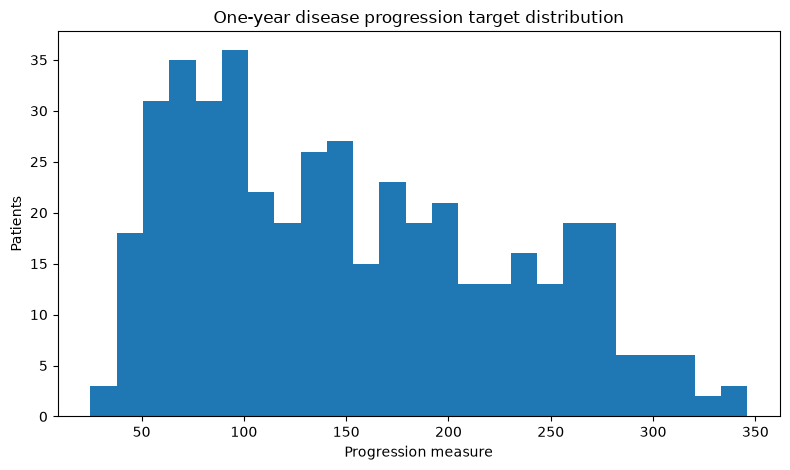

In [4]:
target_summary = pd.Series({
    "patients": len(y),
    "mean_progression": y.mean(),
    "median_progression": y.median(),
    "std_progression": y.std(),
    "min_progression": y.min(),
    "max_progression": y.max()
})
display(target_summary.to_frame("value"))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(y, bins=25)
ax.set_title("One-year disease progression target distribution")
ax.set_xlabel("Progression measure")
ax.set_ylabel("Patients")
plt.tight_layout()
plt.show()

,correlation_with_progression
BMI,0.5865
Serum triglyceride-related signal,0.5659
Average blood pressure,0.4415
Total cholesterol / HDL,0.4305
HDL,-0.3948
Blood glucose,0.3825
Total serum cholesterol,0.2120
Age (years),0.1879
LDL,0.1741
Sex code,0.0431


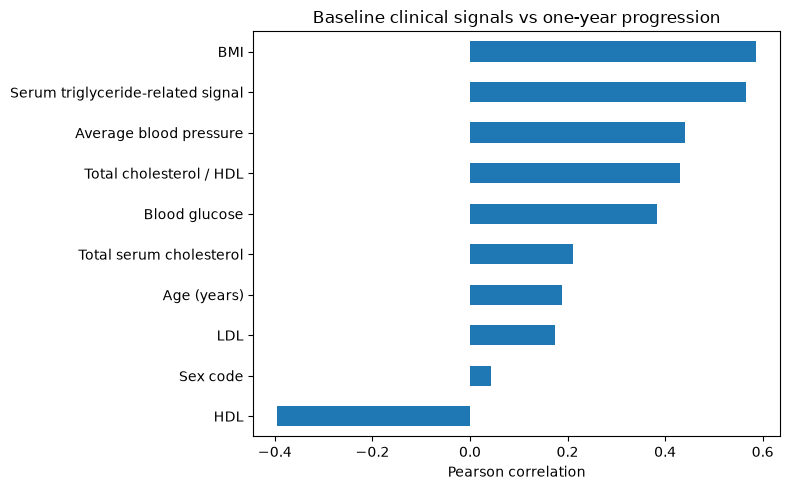

In [5]:
correlations = X.assign(target=y.values).corr(numeric_only=True)["target"].drop("target").sort_values(key=np.abs, ascending=False)
display(correlations.to_frame("correlation_with_progression"))

fig, ax = plt.subplots(figsize=(8, 5))
correlations.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Baseline clinical signals vs one-year progression")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 4. Leakage-safe train / validation / test split

Model selection and interval width are determined using validation data only. The final test set remains untouched until the end.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "patients": [len(X_train), len(X_val), len(X_test)],
    "target_mean": [y_train.mean(), y_val.mean(), y_test.mean()],
    "target_std": [y_train.std(), y_val.std(), y_test.std()]
}, index=["train","validation","test"])
display(split_summary)

,patients,target_mean,target_std
train,265,151.0264,77.4771
validation,88,145.0568,76.3622
test,89,162.4270,76.4869


## 5. Regression models — predict future disease progression

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(
    n_estimators=600,
    min_samples_leaf=4,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=350,
    max_leaf_nodes=15,
    l2_regularization=2.0,
    random_state=RANDOM_STATE
)
hgb.fit(X_train, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
val_pred_rf = rf.predict(X_val)
val_pred_hgb = hgb.predict(X_val)

print("Models trained.")

Models trained.


In [8]:
def regression_metrics(name, y_true, pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "R2": r2_score(y_true, pred)
    }

validation_results = pd.DataFrame([
    regression_metrics("Ridge", y_val, val_pred_ridge),
    regression_metrics("Random Forest", y_val, val_pred_rf),
    regression_metrics("HistGradientBoosting", y_val, val_pred_hgb)
]).set_index("model").sort_values("MAE")

display(validation_results.style.format({
    "MAE":"{:.2f}",
    "RMSE":"{:.2f}",
    "R2":"{:.4f}"
}))

best_regression_name = validation_results.index[0]
print("Validation-selected regression model:", best_regression_name)

,MAE,RMSE,R2
model,,,
Ridge,38.50,49.37,0.5771
Random Forest,41.76,52.68,0.5186
HistGradientBoosting,44.80,58.19,0.4126


Validation-selected regression model: Ridge


## 6. Distribution-free uncertainty interval

Absolute residuals on the validation set estimate a 90% prediction-error band. The interval is frozen before final test evaluation.

Frozen 90% residual interval half-width: 83.46 progression points


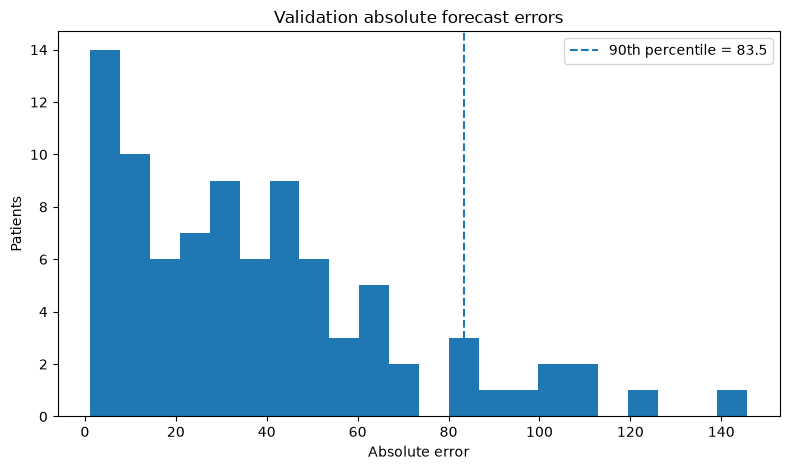

In [9]:
val_prediction_map = {
    "Ridge": val_pred_ridge,
    "Random Forest": val_pred_rf,
    "HistGradientBoosting": val_pred_hgb
}
selected_val_pred = val_prediction_map[best_regression_name]

absolute_residuals = np.abs(y_val.to_numpy() - selected_val_pred)
interval_q90 = float(np.quantile(absolute_residuals, 0.90))

print(f"Frozen 90% residual interval half-width: {interval_q90:.2f} progression points")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(absolute_residuals, bins=22)
ax.axvline(interval_q90, linestyle="--", label=f"90th percentile = {interval_q90:.1f}")
ax.set_title("Validation absolute forecast errors")
ax.set_xlabel("Absolute error")
ax.set_ylabel("Patients")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Separate high-progression early-warning classifier

The high-risk definition is created from the **training target only**: progression at or above the training-set 75th percentile.

In [10]:
risk_threshold = float(y_train.quantile(0.75))
y_train_risk = (y_train >= risk_threshold).astype(int)
y_val_risk = (y_val >= risk_threshold).astype(int)
y_test_risk = (y_test >= risk_threshold).astype(int)

logit = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)
logit.fit(X_train_scaled, y_train_risk)

rf_clf = RandomForestClassifier(
    n_estimators=700,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train_risk)

val_prob_logit = logit.predict_proba(X_val_scaled)[:,1]
val_prob_rf = rf_clf.predict_proba(X_val)[:,1]

def classification_metrics(name, y_true, prob, threshold=0.50):
    pred = (prob >= threshold).astype(int)
    return {
        "model": name,
        "ROC_AUC": roc_auc_score(y_true, prob),
        "PR_AUC": average_precision_score(y_true, prob),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0)
    }

classifier_results = pd.DataFrame([
    classification_metrics("Logistic Regression", y_val_risk, val_prob_logit),
    classification_metrics("Random Forest", y_val_risk, val_prob_rf)
]).set_index("model").sort_values("PR_AUC", ascending=False)

display(classifier_results.style.format({
    "ROC_AUC":"{:.4f}",
    "PR_AUC":"{:.4f}",
    "precision":"{:.2%}",
    "recall":"{:.2%}",
    "F1":"{:.4f}"
}))

best_classifier_name = classifier_results.index[0]
print(f"Training-defined high-risk threshold: {risk_threshold:.1f}")
print("Validation-selected classifier:", best_classifier_name)

,ROC_AUC,PR_AUC,precision,recall,F1
model,,,,,
Logistic Regression,0.9483,0.8929,62.07%,81.82%,0.7059
Random Forest,0.9091,0.7941,77.78%,63.64%,0.7000


Training-defined high-risk threshold: 202.0
Validation-selected classifier: Logistic Regression


## 8. Threshold selection prioritising recall

For an early-warning queue, missed high-risk cases matter. The operating threshold is selected on validation data to maximise F1 while requiring at least 70% recall when possible.

In [11]:
selected_val_prob = val_prob_rf if best_classifier_name == "Random Forest" else val_prob_logit

threshold_grid = np.linspace(0.05, 0.95, 181)
rows = []
for t in threshold_grid:
    pred = (selected_val_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_val_risk, pred, zero_division=0),
        "recall": recall_score(y_val_risk, pred, zero_division=0),
        "F1": f1_score(y_val_risk, pred, zero_division=0)
    })

threshold_table = pd.DataFrame(rows)
eligible = threshold_table.loc[threshold_table["recall"] >= 0.70]
if len(eligible):
    chosen = eligible.sort_values(["F1","precision"], ascending=False).iloc[0]
else:
    chosen = threshold_table.sort_values("F1", ascending=False).iloc[0]

risk_operating_threshold = float(chosen["threshold"])
display(threshold_table.sort_values("F1", ascending=False).head(10))
print(f"Frozen clinical-review threshold: {risk_operating_threshold:.3f}")
print(f"Validation recall at threshold: {chosen['recall']:.2%}")
print(f"Validation precision at threshold: {chosen['precision']:.2%}")

,threshold,precision,recall,F1
134,0.7200,0.8500,0.7727,0.8095
138,0.7400,0.8889,0.7273,0.8000
139,0.7450,0.8889,0.7273,0.8000
129,0.6950,0.8095,0.7727,0.7907
125,0.6750,0.8095,0.7727,0.7907
133,0.7150,0.8095,0.7727,0.7907
131,0.7050,0.8095,0.7727,0.7907
130,0.7000,0.8095,0.7727,0.7907
132,0.7100,0.8095,0.7727,0.7907
128,0.6900,0.8095,0.7727,0.7907


Frozen clinical-review threshold: 0.720
Validation recall at threshold: 77.27%
Validation precision at threshold: 85.00%


## 9. Untouched final test evaluation

In [12]:
test_regression_predictions = {
    "Ridge": ridge.predict(X_test_scaled),
    "Random Forest": rf.predict(X_test),
    "HistGradientBoosting": hgb.predict(X_test)
}
test_pred = test_regression_predictions[best_regression_name]

test_regression_result = regression_metrics(best_regression_name, y_test, test_pred)
display(pd.DataFrame([test_regression_result]).set_index("model").style.format({
    "MAE":"{:.2f}",
    "RMSE":"{:.2f}",
    "R2":"{:.4f}"
}))

lower = test_pred - interval_q90
upper = test_pred + interval_q90
interval_coverage = np.mean((y_test.to_numpy() >= lower) & (y_test.to_numpy() <= upper))
print(f"Frozen 90% residual-band test coverage: {interval_coverage:.2%}")

,MAE,RMSE,R2
model,,,
Ridge,46.88,57.23,0.4338


Frozen 90% residual-band test coverage: 85.39%


,ROC_AUC,PR_AUC,precision,recall,F1
model,,,,,
Logistic Regression,0.8376,0.7482,76.47%,41.94%,0.5417


                        precision    recall  f1-score   support

Lower progression risk       0.75      0.93      0.83        58
 High progression risk       0.76      0.42      0.54        31

              accuracy                           0.75        89
             macro avg       0.76      0.68      0.69        89
          weighted avg       0.76      0.75      0.73        89



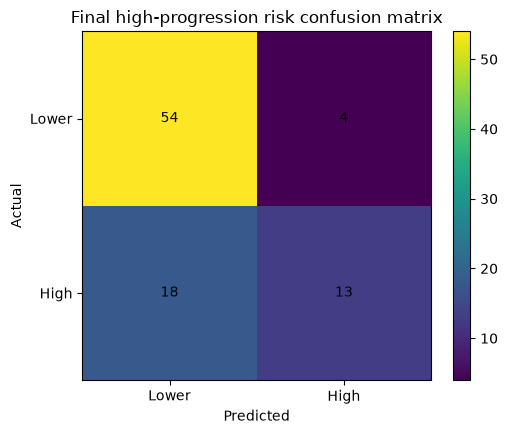

In [13]:
test_prob_logit = logit.predict_proba(X_test_scaled)[:,1]
test_prob_rf = rf_clf.predict_proba(X_test)[:,1]
test_prob = test_prob_rf if best_classifier_name == "Random Forest" else test_prob_logit
test_pred_risk = (test_prob >= risk_operating_threshold).astype(int)

test_classification_result = classification_metrics(
    best_classifier_name,
    y_test_risk,
    test_prob,
    risk_operating_threshold
)

display(pd.DataFrame([test_classification_result]).set_index("model").style.format({
    "ROC_AUC":"{:.4f}",
    "PR_AUC":"{:.4f}",
    "precision":"{:.2%}",
    "recall":"{:.2%}",
    "F1":"{:.4f}"
}))

print(classification_report(
    y_test_risk,
    test_pred_risk,
    target_names=["Lower progression risk","High progression risk"],
    zero_division=0
))

cm = confusion_matrix(y_test_risk, test_pred_risk)
fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(cm)
ax.set_title("Final high-progression risk confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0,1], ["Lower","High"])
ax.set_yticks([0,1], ["Lower","High"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. Prediction quality visualisation

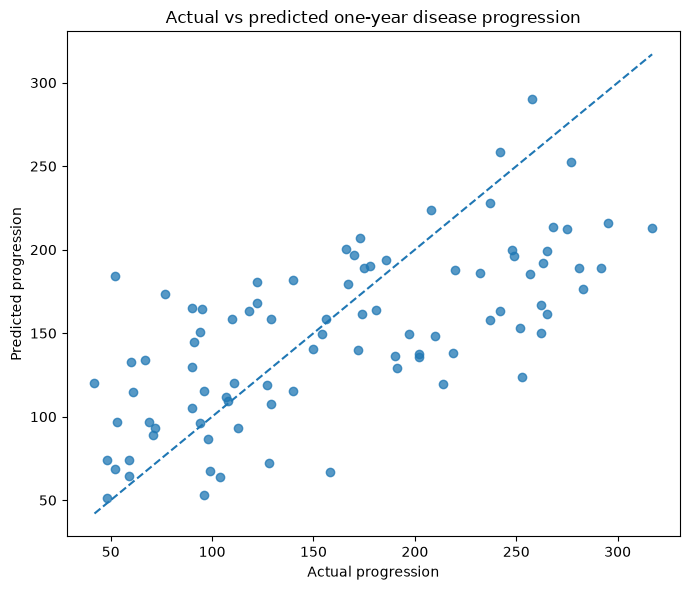

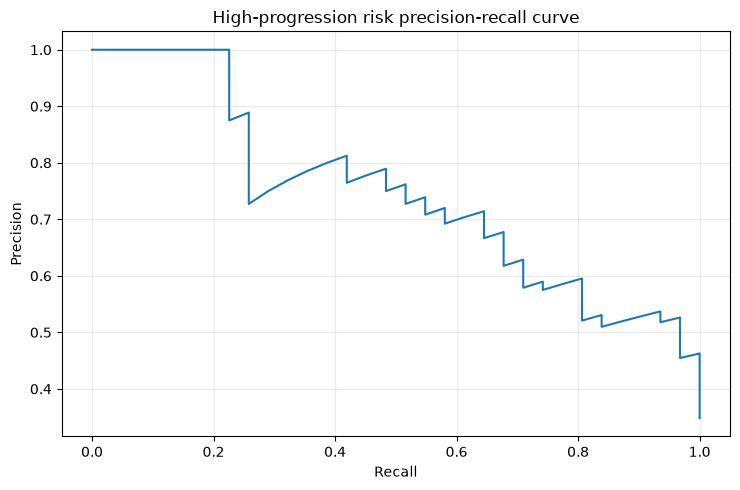

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, test_pred, alpha=0.75)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title("Actual vs predicted one-year disease progression")
ax.set_xlabel("Actual progression")
ax.set_ylabel("Predicted progression")
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test_risk, test_prob)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(recall, precision)
ax.set_title("High-progression risk precision-recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Explainability with permutation importance

Permutation importance asks how much predictive performance deteriorates when each baseline feature is disrupted. Age and sex are included in this analysis rather than silently removed.

,permutation_importance
BMI,7.9809
Serum triglyceride-related signal,7.6824
Average blood pressure,2.4257
HDL,1.7980
Sex code,1.3827
Total cholesterol / HDL,1.0849
Age (years),0.2276
Blood glucose,0.1023
LDL,-0.1175
Total serum cholesterol,-0.3421


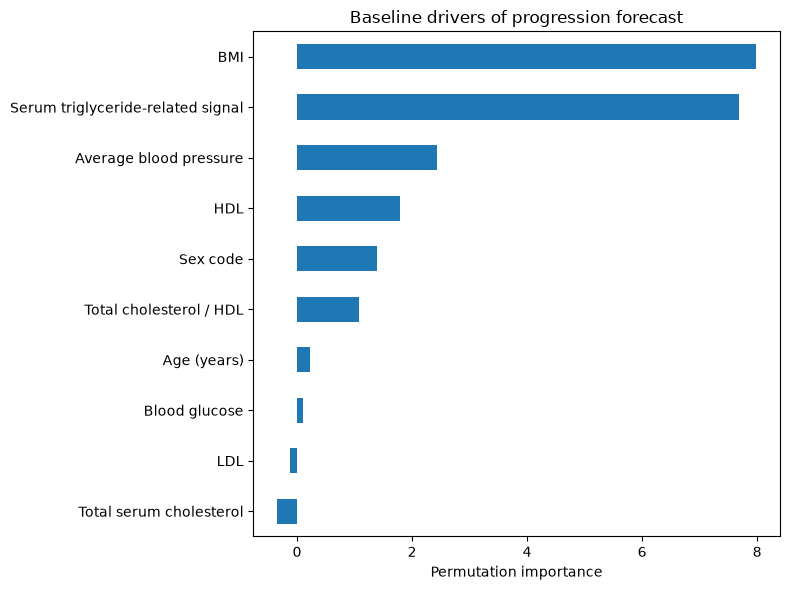

In [15]:
selected_reg_model = {
    "Ridge": ridge,
    "Random Forest": rf,
    "HistGradientBoosting": hgb
}[best_regression_name]

if best_regression_name == "Ridge":
    perm = permutation_importance(
        selected_reg_model, X_test_scaled, y_test,
        n_repeats=50, random_state=RANDOM_STATE,
        scoring="neg_mean_absolute_error"
    )
else:
    perm = permutation_importance(
        selected_reg_model, X_test, y_test,
        n_repeats=50, random_state=RANDOM_STATE,
        scoring="neg_mean_absolute_error"
    )

importance = pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

display(importance.to_frame("permutation_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Baseline drivers of progression forecast")
ax.set_xlabel("Permutation importance")
plt.tight_layout()
plt.show()

## 12. Subgroup performance audit

Because age and sex are retained as model inputs, the notebook also checks whether forecast error differs materially across **age bands** and the two **source sex-code groups**.

This is a small educational dataset, so subgroup results are descriptive rather than evidence of clinical fairness or safety.

Age-band audit:


,patients,MAE,high_risk_prevalence,alert_rate
group,,,,
<40,23,42.76,17.39%,4.35%
40-49,21,39.04,19.05%,23.81%
50-59,25,54.00,52.00%,24.00%
60+,20,50.96,50.00%,25.00%


Sex-code audit:


,patients,MAE,high_risk_prevalence,alert_rate
group,,,,
1.0,45,44.88,28.89%,17.78%
2.0,44,48.94,40.91%,20.45%


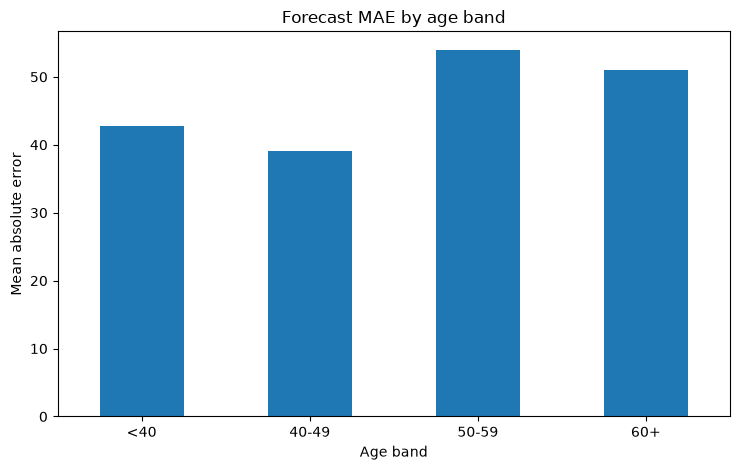

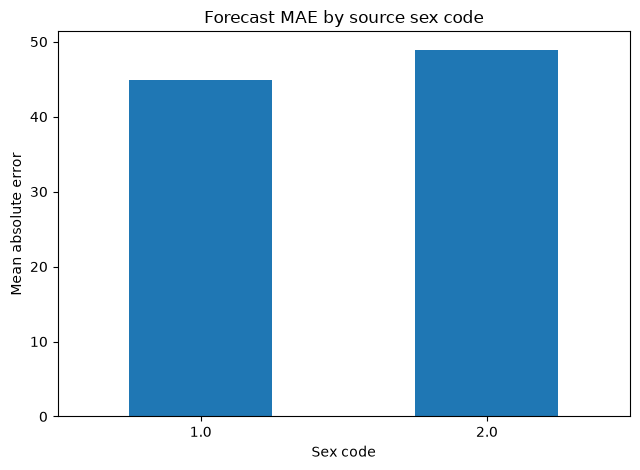

In [16]:
audit = X_test[["Age (years)","Sex code"]].copy().reset_index(drop=True)
audit["actual"] = y_test.reset_index(drop=True)
audit["prediction"] = np.asarray(test_pred)
audit["absolute_error"] = np.abs(audit["actual"] - audit["prediction"])
audit["high_risk_actual"] = y_test_risk.reset_index(drop=True).to_numpy()
audit["high_risk_predicted"] = np.asarray(test_pred_risk)

age_bins = [0, 39, 49, 59, 200]
age_labels = ["<40","40-49","50-59","60+"]
audit["age_band"] = pd.cut(audit["Age (years)"], bins=age_bins, labels=age_labels, include_lowest=True)

def subgroup_report(frame, group_col):
    rows = []
    for group, g in frame.groupby(group_col, observed=True):
        rows.append({
            "group": str(group),
            "patients": len(g),
            "MAE": g["absolute_error"].mean(),
            "high_risk_prevalence": g["high_risk_actual"].mean(),
            "alert_rate": g["high_risk_predicted"].mean()
        })
    return pd.DataFrame(rows).set_index("group")

age_audit = subgroup_report(audit, "age_band")
sex_audit = subgroup_report(audit, "Sex code")

print("Age-band audit:")
display(age_audit.style.format({"MAE":"{:.2f}","high_risk_prevalence":"{:.2%}","alert_rate":"{:.2%}"}))
print("Sex-code audit:")
display(sex_audit.style.format({"MAE":"{:.2f}","high_risk_prevalence":"{:.2%}","alert_rate":"{:.2%}"}))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
age_audit["MAE"].plot(kind="bar", ax=ax)
ax.set_title("Forecast MAE by age band")
ax.set_ylabel("Mean absolute error")
ax.set_xlabel("Age band")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.8))
sex_audit["MAE"].plot(kind="bar", ax=ax)
ax.set_title("Forecast MAE by source sex code")
ax.set_ylabel("Mean absolute error")
ax.set_xlabel("Sex code")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 13. Ranked clinical-review queue

The queue is anonymised with synthetic review IDs. It ranks by predicted progression and high-risk probability.

Age and the source sex code remain visible because this version intentionally retains those baseline characteristics.

This is **not** a treatment recommendation; it is an analytical triage demonstration.

In [17]:
review = X_test.copy().reset_index(drop=True)
review["actual_progression"] = y_test.reset_index(drop=True)
review["predicted_progression"] = test_pred
review["prediction_lower"] = lower
review["prediction_upper"] = upper
review["high_risk_probability"] = test_prob
review["high_risk_flag"] = test_pred_risk

review["review_id"] = [f"CASE-{i+1:03d}" for i in range(len(review))]
review["priority_score"] = (
    0.60 * (review["predicted_progression"] - review["predicted_progression"].min()) /
    (review["predicted_progression"].max() - review["predicted_progression"].min() + 1e-9)
    + 0.40 * review["high_risk_probability"]
)

queue = review.sort_values(["high_risk_flag","priority_score"], ascending=[False,False])

queue_view = queue[[
    "review_id","Age (years)","Sex code",
    "predicted_progression","prediction_lower","prediction_upper",
    "high_risk_probability","high_risk_flag",
    "BMI","Average blood pressure","HDL","Blood glucose"
]].head(25)

print("Top 25 analytical review cases:")
display(queue_view.style.format({
    "Age (years)":"{:.0f}",
    "Sex code":"{:.0f}",
    "predicted_progression":"{:.1f}",
    "prediction_lower":"{:.1f}",
    "prediction_upper":"{:.1f}",
    "high_risk_probability":"{:.2%}",
    "BMI":"{:.2f}",
    "Average blood pressure":"{:.1f}",
    "HDL":"{:.1f}",
    "Blood glucose":"{:.1f}"
}))

queue.to_csv("healthcare_progression_review_queue.csv", index=False)
age_audit.to_csv("healthcare_age_band_audit.csv")
sex_audit.to_csv("healthcare_sex_code_audit.csv")
print("Review queue and subgroup audits exported.")

Top 25 analytical review cases:


,review_id,Age (years),Sex code,predicted_progression,prediction_lower,prediction_upper,high_risk_probability,high_risk_flag,BMI,Average blood pressure,HDL,Blood glucose
37,CASE-038,55,1,290.1,206.6,373.5,98.74%,1,36.60,113.0,43.0,97.0
65,CASE-066,46,2,258.2,174.7,341.7,96.47%,1,42.20,99.0,44.0,99.0
81,CASE-082,51,2,252.6,169.1,336.0,96.99%,1,32.80,112.0,37.0,109.0
2,CASE-003,69,1,228.0,144.6,311.5,84.95%,1,37.00,103.0,55.0,90.0
77,CASE-078,57,2,224.0,140.5,307.5,87.37%,1,29.40,109.0,31.0,92.0
5,CASE-006,60,2,215.8,132.3,299.2,88.12%,1,33.00,97.0,45.0,112.0
44,CASE-045,49,2,213.8,130.3,297.3,88.76%,1,31.90,94.0,34.0,122.0
0,CASE-001,62,2,212.2,128.7,295.6,85.46%,1,31.80,115.0,44.0,98.0
32,CASE-033,41,1,212.8,129.4,296.3,80.90%,1,30.80,81.0,28.0,123.0
16,CASE-017,51,1,207.2,123.7,290.6,84.23%,1,31.50,93.0,49.0,117.0


Review queue and subgroup audits exported.


## 14. Executive summary

In [18]:
print(f"""
HEALTHCARE DISEASE-PROGRESSION EARLY-WARNING SUMMARY
----------------------------------------------------
Dataset: scikit-learn diabetes progression dataset
Patients: {len(X):,}
Prediction horizon: one year after baseline
Model inputs: age, sex, BMI, blood pressure + six serum measures
Age used: YES
Sex used: YES (source numeric code)
Patient identifiers used: NO

Selected regression model: {best_regression_name}
Test MAE: {test_regression_result['MAE']:.2f}
Test RMSE: {test_regression_result['RMSE']:.2f}
Test R²: {test_regression_result['R2']:.4f}
Residual-band test coverage: {interval_coverage:.2%}

Selected high-risk classifier: {best_classifier_name}
Test ROC-AUC: {test_classification_result['ROC_AUC']:.4f}
Test PR-AUC: {test_classification_result['PR_AUC']:.4f}
Test precision: {test_classification_result['precision']:.2%}
Test recall: {test_classification_result['recall']:.2%}
Test F1: {test_classification_result['F1']:.4f}

Age-band MAE range: {age_audit['MAE'].min():.2f} -> {age_audit['MAE'].max():.2f}
Sex-code MAE range: {sex_audit['MAE'].min():.2f} -> {sex_audit['MAE'].max():.2f}

The project separates continuous progression forecasting from a high-risk
alert layer, freezes model and threshold choices before the test set,
retains age and sex inputs, audits subgroup behaviour, adds uncertainty
bands and produces an anonymised analytical review queue.

Educational research demonstration only — not a clinical diagnostic system.
""")


HEALTHCARE DISEASE-PROGRESSION EARLY-WARNING SUMMARY
----------------------------------------------------
Dataset: scikit-learn diabetes progression dataset
Patients: 442
Prediction horizon: one year after baseline
Model inputs: age, sex, BMI, blood pressure + six serum measures
Age used: YES
Sex used: YES (source numeric code)
Patient identifiers used: NO

Selected regression model: Ridge
Test MAE: 46.88
Test RMSE: 57.23
Test R²: 0.4338
Residual-band test coverage: 85.39%

Selected high-risk classifier: Logistic Regression
Test ROC-AUC: 0.8376
Test PR-AUC: 0.7482
Test precision: 76.47%
Test recall: 41.94%
Test F1: 0.5417

Age-band MAE range: 39.04 -> 54.00
Sex-code MAE range: 44.88 -> 48.94

The project separates continuous progression forecasting from a high-risk
alert layer, freezes model and threshold choices before the test set,
retains age and sex inputs, audits subgroup behaviour, adds uncertainty
bands and produces an anonymised analytical review queue.

Educational research d

### Production roadmap
- external validation on a substantially larger contemporary cohort;
- patient-disjoint temporal evaluation where repeated records exist;
- prospective calibration;
- age/sex and intersectional subgroup performance audits with confidence intervals;
- missingness-aware longitudinal vitals / laboratory modelling;
- clinically validated risk thresholds and escalation protocols;
- uncertainty-aware abstention for out-of-distribution patients;
- model drift and data-quality monitoring;
- clinician-in-the-loop review before any real-world use.

### Interview defence
**“I retained age and sex because they are part of the source clinical baseline, rather than automatically deleting potentially relevant variables. I used all ten baseline features, selected models only on validation data, froze the uncertainty band and high-risk threshold before testing, and then explicitly audited forecast error across age bands and sex-code groups. I would still require external prospective validation before clinical use.”**